In [ ]:
!pip install -U sentence-transformers


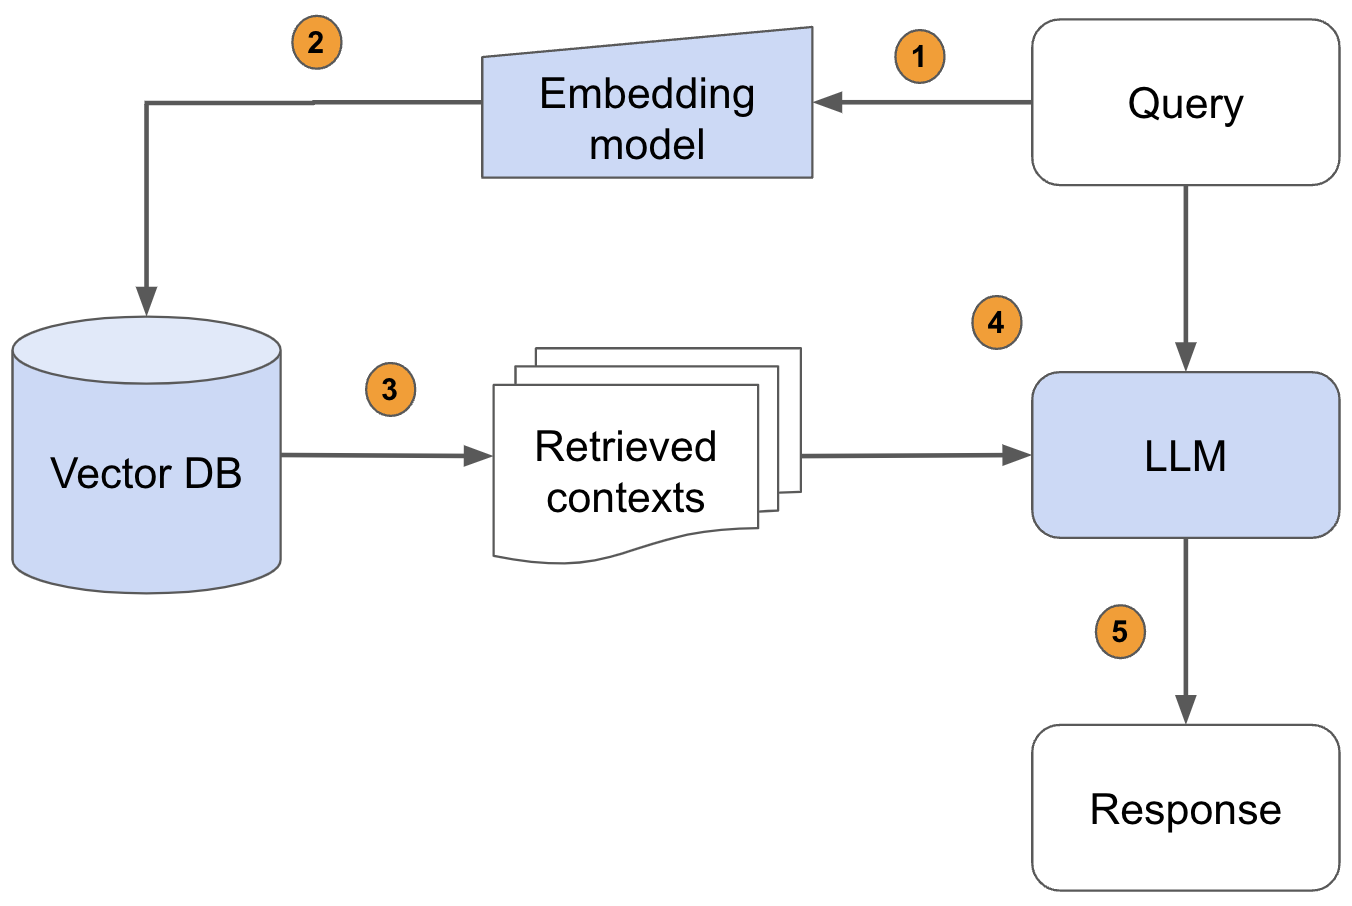

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")
data_source = [
    "Matrix multiplication and partial differential equations are essential for understanding deep learning.",
    "To achieve a muscle-up, you need explosive pulling power and good transition technique.",
    "The TaToBa combo uses the Taka, Tora, and Batta core medals.",
    "Retrieval-Augmented Generation helps AI models verify clinical guidelines accurately."
]
#เช็คว่า embed มา similar ใกล้เคียงมั้ย
embeddings = model.encode(data_source) #indexer
try:
    print(embeddings.shape)
    print("embedding success")
except:
    print("import error")
# สร้าง data store
datastore = {}

for i in range(len(data_source)):
    text = data_source[i]
    vector = embeddings[i]
    datastore[text] = vector

In [ ]:
#ลองเล่น
query = "How do I build muscle?"
query_embedding = model.encode(query)
print(query_embedding.shape)

ต่อมาลองทำ retrieval

In [ ]:
from sentence_transformers import util
try: score = util.cos_sim(query_embedding, embeddings[1]) # ต้องเอ่า vector เทียบ vector อันนี้คืเเค่ 1 ตัว
except:
    print("error")

# ถ้าอยากเทียบหมด
scores = util.cos_sim(query_embedding, embeddings)
print(scores)

In [ ]:
best_indexes = scores.argmax()
retrieved_text = data_source[best_indexes]
print(retrieved_text)

In [ ]:
prompt = f"Context: {retrieved_text} | Question: {query}"
print(prompt)
from transformers import pipeline

# Load a tiny local LLM
llm = pipeline("text2text-generation", model="google/flan-t5-small")

# Generate the response using your prompt
answer = llm(prompt)
print(answer)

ลอง eval ด้วย LLm judge

In [ ]:
eval_prompt = f"""
Role: You are an AI teacher grading a test.
Context: The user asked '{query}'. The provided fact is '{retrieved_text}'. The AI answered '{answer}'.
Task: Did the AI answer the question correctly using only the provided fact? Reply with only 'Yes' or 'No'.
"""

print(eval_prompt)
evaluation = llm(eval_prompt)
print(evaluation)